[-5.         -0.         -1.66666667 -1.66666667 -0.          3.33333333]


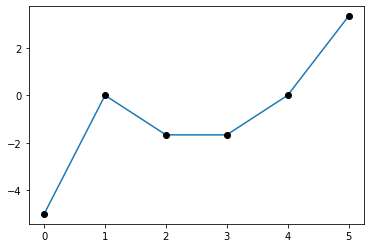

In [41]:
#### Comp.Phys.HW4.Q1 : Exercise 6.7 -- A chain of resistors
import numpy as np
from numpy import copy, empty, zeros
from pylab import plot, show

# Banded func.
def banded(Aa,va,up,down):
    A = copy(Aa)
    v = copy(va)
    N = len(v)
    
    # Gaussian elim.
    for m in range(N):
        
        # Normalize
        div = A[up,m]
        
        # Update the vector
        v[m] /= div
        for k in range(1,down+1):
            if m + k < N:
                v[m + k] -= A[up + k, m] * v[m]
        
        # Normalize pivot row of A -- subtract from lower ones
        for i in range(up):
            j = m + up - i
            if j < N:
                A[i,j] /= div
                for k in range(1,down+1):
                    A[i + k, j] -= A[up + k, m] * A[i,j]
                    
    # Backsubstitution
    for m in range(N - 2, -1, -1):
        for i in range(up):
            j = m + up - i
            if j < N:
                v[m] -= A[i,j] * v[j]
                
    return v

# constants
C = 5.0
N = 6

# setting up init. values of array
A = empty([5,N],float)

A[0,:] = -1.0
A[1,:] = -1.0
A[2,:] = -1.0
A[3,:] = -1.0
A[4,:] = -1.0
A[0,2] = 3.0
A[1,2] = 4.0
A[2,2] = 4.0
A[3,3] = 4.0
A[4,4] = 3.0


v = zeros(N,float)
v[0] = C
v[1] = C

# solving equations
x = banded(A,v,0,4) # 1+up+down --> 1+0+4 = [5,N] matrix above
print(x)

plot(x)
plot(x, "ko")
show()

# values are between 0 and 5 volts
# domain and range of axes resemble the example from the slides
# should be good unless matrix was setup incorrectly

In [42]:
# Comp.Phys.HW4.Q2 : Exercise 6.13 -- Wien's displacement constant

import math
import numpy as np

def f(x):
     return 5 * np.exp(-x) + x - 5

    
a = -4.9
b = 4.9
midpoint = 0.5 * (a + b)
evaluate = f(midpoint)
h = 6.626e-34
c = 3.0e8
kb = 1.380649e-23

if (f(a) * f(b) > 0):print("No good...initial endpoints have the same sign.")
nmax = 10000
n = 0
epsilon = 1e-6

while ((abs(b - a) > epsilon) and n < nmax):
    if ((f(midpoint) * f(a)) > 0): a = midpoint
    else: b = midpoint
    midpoint = 0.5 * (a + b)
    n = n + 1
    
print("It took", n, "iterations", " and midpoint = ", midpoint)
        
b = (h * c) / (kb * midpoint)    
print("Wien Displacement Constant: ", b)

# Surface Temp of Sun
# lambda = b/T

wavelength = 502e-9 # Sun's emitted radiation

# we need b/lambda

T = b / wavelength
print("Sun's Surface Temp.: ", T)

# Obviously I did something wrong, because I don't believe 
# that this is the surface temp of the sun

It took 24 iterations  and midpoint =  -2.920627593994141e-07
Wien Displacement Constant:  -49296.17463517341
Sun's Surface Temp.:  -98199551066.08249


In [ ]:
# Comp.Phys.HW4.Q3 : Exercise 6.18 -- Temp. of light bulb

import matplotlib.pyplot as plt
import numpy as np
from numpy import linspace, pi, cos, tan, ones, copy

h = 6.626e-34 # Planck's const.
c = 3.0e8 # speed of light
lam1 = 390e-9 # lower end of vis. spec.
lam2 = 750e-9 # upper end of vis. spec.
Kb = 1.380649e-23 # Boltzmann const.
N = 100

def gaussxw(N):
    a = linspace(3, 4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))
    
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N, float)
        p1 = copy(x)
        for k in range(1,N):
            p0, p1 = p1, ((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1) * (p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))
    
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)
    return x,w


def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a), 0.5*(b-a)*w


def integrateGauss(N,a,b,f):
    integral = 0.0
    x,w = gaussxwab(N,a,b)
    
    for k in range(N):
        integral = integral+w[k]*f(x[k])
    return integral


# efficiency func
def n(T):
    
    x1 = (h * c) / (lam1 * Kb * T)
    x2 = (h * c) / (lam2 * Kb * T)
    
    integral = integrateGauss(N,x2,x1,f)
    return integral

def f(x):
    return (15 / np.pi**4) * x**3 / (np.exp(x) - 1)


#setting up the plot
temps = np.linspace(300, 10000, N)
effic = [n(T) for T in temps]
plt.plot(temps, effic)
plt.xlabel('Temperature (K)')
plt.ylabel('Efficiency (K)')
plt.title('Efficiency of Temperature')
plt.show()


# What is the max effic. temp.? 







# Is the temp. found above practical for tungsten-filament lightbulb?
# No. Where the graph shows a maximum, the temperature is too hot for a tungsten filament lightbulb
# Tungsten should be around 3000 Kelvin